
# Cardiovascular Disease Risk Prediction using Machine Learning


## Student A - Binary Classification

### Problem Statement
Build a machine learning model that predicts whether a patient is at risk of
cardiovascular disease based on clinical measurements.

### Algorithms
- Logistic Regression
- Random Forest
- XGBoost

### Objective
- Binary Classification
- High Recall
- Explainable Prediction
- Deployment Ready

### Dataset
Cardiovascular Disease Dataset (70,000 Records)
Target:
0 → No Disease
1 → Disease

In [1]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# ---------------- Numerical Computing ----------------
import numpy as np
import pandas as pd

# ---------------- Data Visualization ----------------
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Machine Learning ----------------
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# ---------------- Evaluation Metrics ----------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

# ---------------- Model Saving ----------------
import joblib

# ---------------- System Resource Analysis ----------------
import os
import time
import psutil
import tracemalloc

# ---------------- Ignore Warnings ----------------
import warnings
warnings.filterwarnings("ignore")

# ---------------- Plot Style ----------------
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


# Load Dataset

In [2]:
# =============================================================================
# LOAD DATASET
# =============================================================================

# Load Dataset
df = pd.read_csv(r"..\data\raw\cardio_train.csv", sep=";")

# Verify Dataset Loaded Successfully
print("="*70)
print("DATASET LOADED SUCCESSFULLY")
print("="*70)

print(f"Dataset Shape : {df.shape}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst Five Rows:")
display(df.head())

DATASET LOADED SUCCESSFULLY
Dataset Shape : (70000, 13)

Column Names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

First Five Rows:


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


# EDA

In [3]:
# =============================================================================
# DATA CLEANING & FEATURE ENGINEERING
# =============================================================================

# Create a copy
df_clean = df.copy()

# -----------------------------------------------------
# Remove ID Column
# -----------------------------------------------------
df_clean.drop(columns=["id"], inplace=True)

# -----------------------------------------------------
# Convert Age (Days → Years)
# -----------------------------------------------------
df_clean["age"] = (df_clean["age"] / 365).round(1)

# -----------------------------------------------------
# Remove Duplicate Records
# -----------------------------------------------------
print(f"Duplicate Rows Before Removal : {df_clean.duplicated().sum()}")

df_clean.drop_duplicates(inplace=True)

print(f"Dataset Shape After Removing Duplicates : {df_clean.shape}")

# -----------------------------------------------------
# Remove Invalid Blood Pressure Values
# -----------------------------------------------------
df_clean = df_clean[
    (df_clean["ap_hi"] > 0) &
    (df_clean["ap_lo"] > 0) &
    (df_clean["ap_hi"] >= df_clean["ap_lo"])
]

# -----------------------------------------------------
# Remove Unrealistic Height & Weight
# -----------------------------------------------------
df_clean = df_clean[
    (df_clean["height"] >= 100) &
    (df_clean["height"] <= 250)
]

df_clean = df_clean[
    (df_clean["weight"] >= 30) &
    (df_clean["weight"] <= 250)
]

# -----------------------------------------------------
# Create BMI Feature
# -----------------------------------------------------
height_m = df_clean["height"] / 100

df_clean["BMI"] = df_clean["weight"] / (height_m ** 2)

print("\nFinal Dataset Shape :", df_clean.shape)

display(df_clean.head())

Duplicate Rows Before Removal : 665
Dataset Shape After Removing Duplicates : (69335, 12)

Final Dataset Shape : (68046, 13)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50.4,2,168,62.0,110,80,1,1,0,0,1,0,21.967120
1,55.4,1,156,85.0,140,90,3,1,0,0,1,1,34.927679
2,51.7,1,165,64.0,130,70,3,1,0,0,0,1,23.507805
3,48.3,2,169,82.0,150,100,1,1,0,0,1,1,28.710479
4,47.9,1,156,56.0,100,60,1,1,0,0,0,0,23.011177


# Feature Selection

In [4]:
# =============================================================================
# FEATURE SELECTION
# =============================================================================

X = df_clean.drop("cardio", axis=1)
y = df_clean["cardio"]

print("Feature Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

display(X.head())
display(y.head())




# Train-Test Split
# =============================================================================
# TRAIN - TEST SPLIT
# =============================================================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("="*70)
print("TRAIN - TEST SPLIT")
print("="*70)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)





Feature Matrix Shape : (68046, 12)
Target Shape : (68046,)


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,50.4,2,168,62.0,110,80,1,1,0,0,1,21.967120
1,55.4,1,156,85.0,140,90,3,1,0,0,1,34.927679
2,51.7,1,165,64.0,130,70,3,1,0,0,0,23.507805
3,48.3,2,169,82.0,150,100,1,1,0,0,1,28.710479
4,47.9,1,156,56.0,100,60,1,1,0,0,0,23.011177


0    0
1    1
2    1
3    1
4    0
Name: cardio, dtype: int64

TRAIN - TEST SPLIT
Training Features : (47632, 12)
Testing Features  : (20414, 12)
Training Labels   : (47632,)
Testing Labels    : (20414,)


#  MODEL SELECTION   (ML supervised  ALGORITHM) 

# MODEL-1  :    Logistic Regression Training

In [5]:
# =============================================================================
# FEATURE SCALING
# =============================================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Logistic Regression Data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*70)
print("FEATURE SCALING COMPLETED")
print("="*70)

print("Scaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

FEATURE SCALING COMPLETED
Scaled Training Shape : (47632, 12)
Scaled Testing Shape  : (20414, 12)


In [6]:
# =============================================================================
# LOGISTIC REGRESSION
# =============================================================================

lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

start_time = time.time()

lr_model.fit(X_train_scaled, y_train)

lr_training_time = time.time() - start_time

print("="*70)
print("LOGISTIC REGRESSION TRAINED")
print("="*70)

print(f"Training Time : {lr_training_time:.4f} seconds")




# =============================================================================
# LOGISTIC REGRESSION PREDICTION
# =============================================================================

start_time = time.time()

lr_pred = lr_model.predict(X_test_scaled)

lr_prediction_time = time.time() - start_time

lr_probability = lr_model.predict_proba(X_test_scaled)[:,1]

print("="*70)
print("PREDICTION COMPLETED")
print("="*70)

print(f"Prediction Time : {lr_prediction_time:.4f} seconds")











# =============================================================================
# LOGISTIC REGRESSION EVALUATION
# =============================================================================

print("="*70)
print("LOGISTIC REGRESSION PERFORMANCE")
print("="*70)

accuracy = accuracy_score(y_test, lr_pred)
precision = precision_score(y_test, lr_pred)
recall = recall_score(y_test, lr_pred)
f1 = f1_score(y_test, lr_pred)
auc = roc_auc_score(y_test, lr_probability)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC AUC   : {auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, lr_pred))











LOGISTIC REGRESSION TRAINED
Training Time : 0.0315 seconds
PREDICTION COMPLETED
Prediction Time : 0.0010 seconds
LOGISTIC REGRESSION PERFORMANCE
Accuracy  : 0.7217
Precision : 0.7403
Recall    : 0.6786
F1 Score  : 0.7081
ROC AUC   : 0.7834

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.76      0.73     10260
           1       0.74      0.68      0.71     10154

    accuracy                           0.72     20414
   macro avg       0.72      0.72      0.72     20414
weighted avg       0.72      0.72      0.72     20414



# CONFUSION MATRIX

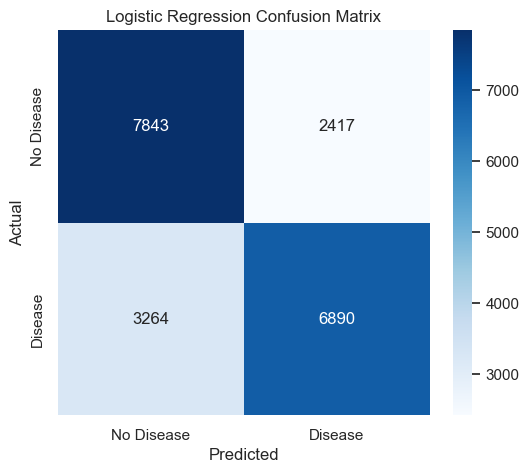

In [7]:
# =============================================================================
# CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

# Random Forest Training

RANDOM FOREST TRAINED
Training Time : 0.9352 seconds
PREDICTION COMPLETED
Prediction Time : 0.0775 seconds
RANDOM FOREST PERFORMANCE
Accuracy  : 0.7069
Precision : 0.7112
Recall    : 0.6915
F1 Score  : 0.7012
ROC AUC   : 0.7653

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.72      0.71     10260
           1       0.71      0.69      0.70     10154

    accuracy                           0.71     20414
   macro avg       0.71      0.71      0.71     20414
weighted avg       0.71      0.71      0.71     20414



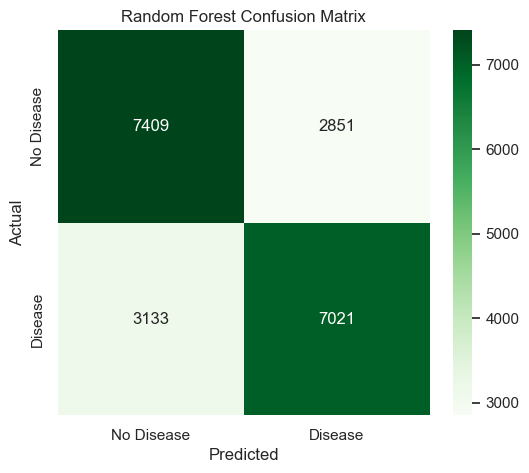

In [8]:
# =============================================================================
# RANDOM FOREST CLASSIFIER
# =============================================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Training Time
start_time = time.time()

rf_model.fit(X_train, y_train)

rf_training_time = time.time() - start_time

print("="*70)
print("RANDOM FOREST TRAINED")
print("="*70)

print(f"Training Time : {rf_training_time:.4f} seconds")









# =============================================================================
# RANDOM FOREST PREDICTION
# =============================================================================

start_time = time.time()

rf_pred = rf_model.predict(X_test)

rf_prediction_time = time.time() - start_time

rf_probability = rf_model.predict_proba(X_test)[:,1]

print("="*70)
print("PREDICTION COMPLETED")
print("="*70)

print(f"Prediction Time : {rf_prediction_time:.4f} seconds")








# =============================================================================
# RANDOM FOREST PERFORMANCE
# =============================================================================

print("="*70)
print("RANDOM FOREST PERFORMANCE")
print("="*70)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_probability)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC AUC   : {rf_auc:.4f}")

print("\nClassification Report")

print(classification_report(y_test, rf_pred))









# =============================================================================
# RANDOM FOREST CONFUSION MATRIX  ---> 
# jo jaisa tha baisa hin model ne pridict kiya 
# TP(disease the, diseas yes pridict kiya),
# TN (disease nahi the, diseas no pridict kiya)   

# jo jaisa tha thik uske bipirit model ne pridict kiya after gitting trained
# FP(disease the, diseas  no pridict kiya,
# FN(disease nahi the, diseas yes pridict kiya)
# =============================================================================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()


# XGBoost

XGBOOST TRAINED
Training Time : 0.4273 seconds
PREDICTION COMPLETED
Prediction Time : 0.0159 seconds
XGBOOST PERFORMANCE
Accuracy  : 0.7310
Precision : 0.7512
Recall    : 0.6866
F1 Score  : 0.7175
ROC AUC   : 0.7967

Classification Report

              precision    recall  f1-score   support

           0       0.71      0.77      0.74     10260
           1       0.75      0.69      0.72     10154

    accuracy                           0.73     20414
   macro avg       0.73      0.73      0.73     20414
weighted avg       0.73      0.73      0.73     20414



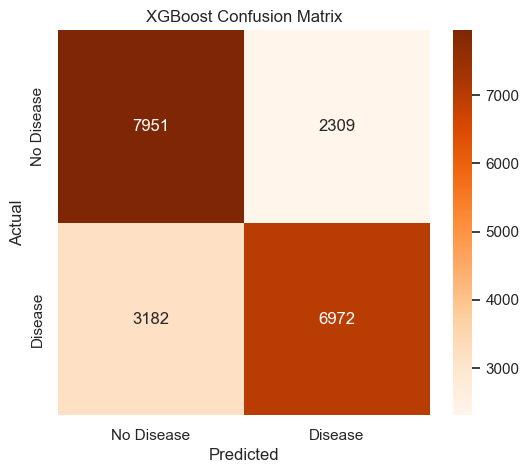

In [9]:
# =============================================================================
# XGBOOST CLASSIFIER  Training
# =============================================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

# Training Time
start_time = time.time()

xgb_model.fit(X_train, y_train)

xgb_training_time = time.time() - start_time

print("="*70)
print("XGBOOST TRAINED")
print("="*70)

print(f"Training Time : {xgb_training_time:.4f} seconds")



# =============================================================================
# XGBOOST PREDICTION
# =============================================================================

start_time = time.time()

xgb_pred = xgb_model.predict(X_test)

xgb_prediction_time = time.time() - start_time

xgb_probability = xgb_model.predict_proba(X_test)[:,1]

print("="*70)
print("PREDICTION COMPLETED")
print("="*70)

print(f"Prediction Time : {xgb_prediction_time:.4f} seconds")











# =============================================================================
# XGBOOST PERFORMANCE
# =============================================================================

print("="*70)
print("XGBOOST PERFORMANCE")
print("="*70)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_probability)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC AUC   : {xgb_auc:.4f}")

print("\nClassification Report\n")

print(classification_report(y_test, xgb_pred))





# =============================================================================
# XGBOOST CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Disease","Disease"],
    yticklabels=["No Disease","Disease"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()




#  GridSearchCV   [cv->   cross validation]


**GridSearchCV divides  in  5 parts  to  entire training data   like 
Fold1
Fold2
Fold3
Fold4
Fold5
internally it'll do  
Train : Fold2+3+4+5
Validate : Fold1

goal---> GridSearchCV automatically finds the best hyperparameters by trying multiple parameter combinations. It uses k-fold cross-validation (5-fold in our project), evaluates every combination using ROC-AUC, and selects the model with the highest average validation performance. This reduces manual tuning and improves model generalization **




**GridSearchCV = Automatic hyperparameter tuning + Cross-validation for selecting the best-performing model**

In [10]:
# =============================================================================
# GRID SEARCH CV - LOGISTIC REGRESSION
# =============================================================================

lr_params = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs", "liblinear"]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=lr_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

start_time = time.time()

lr_grid.fit(X_train_scaled, y_train)

lr_grid_time = time.time() - start_time

print("="*70)
print("BEST LOGISTIC REGRESSION MODEL")
print("="*70)

print("Best Parameters :", lr_grid.best_params_)
print("Best ROC-AUC    :", lr_grid.best_score_)
print(f"Training Time   : {lr_grid_time:.2f} seconds")

best_lr = lr_grid.best_estimator_

BEST LOGISTIC REGRESSION MODEL
Best Parameters : {'C': 10, 'solver': 'liblinear'}
Best ROC-AUC    : 0.7868365592191985
Training Time   : 5.95 seconds


In [11]:
# =============================================================================
# GRID SEARCH CV - RANDOM FOREST
# =============================================================================

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

start_time = time.time()

rf_grid.fit(X_train, y_train)

rf_grid_time = time.time() - start_time

print("="*70)
print("BEST RANDOM FOREST MODEL")
print("="*70)

print("Best Parameters :", rf_grid.best_params_)
print("Best ROC-AUC    :", rf_grid.best_score_)
print(f"Training Time   : {rf_grid_time:.2f} seconds")

best_rf = rf_grid.best_estimator_

BEST RANDOM FOREST MODEL
Best Parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best ROC-AUC    : 0.8003325638259406
Training Time   : 50.72 seconds


In [12]:
# =============================================================================
# GRID SEARCH CV - XGBOOST
# =============================================================================

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_grid=xgb_params,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

start_time = time.time()

xgb_grid.fit(X_train, y_train)

xgb_grid_time = time.time() - start_time

print("="*70)
print("BEST XGBOOST MODEL")
print("="*70)

print("Best Parameters :", xgb_grid.best_params_)
print("Best ROC-AUC    :", xgb_grid.best_score_)
print(f"Training Time   : {xgb_grid_time:.2f} seconds")

best_xgb = xgb_grid.best_estimator_

BEST XGBOOST MODEL
Best Parameters : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best ROC-AUC    : 0.801143821853952
Training Time   : 4.09 seconds


#  Threshold Tuning

In [13]:
# =============================================================================
# THRESHOLD TUNING FOR HIGH RECALL
# =============================================================================

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.05)

results = []

# Use the best model (Logistic Regression example)
probabilities = best_lr.predict_proba(X_test_scaled)[:, 1]

for threshold in thresholds:

    predictions = (probabilities >= threshold).astype(int)

    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    results.append([threshold, precision, recall, f1])

threshold_df = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1 Score"]
)

display(threshold_df)

,Threshold,Precision,Recall,F1 Score
0,0.10,0.504635,0.997242,0.670152
1,0.15,0.517922,0.990447,0.680170
2,0.20,0.534102,0.976364,0.690486
3,0.25,0.557567,0.952433,0.703371
4,0.30,0.586085,0.917569,0.715289
5,0.35,0.618655,0.872661,0.724027
6,0.40,0.657567,0.816033,0.728279
7,0.45,0.700055,0.751625,0.724924
8,0.50,0.740753,0.678452,0.708235
9,0.55,0.771560,0.609710,0.681153


# Plot Precision vs Recall

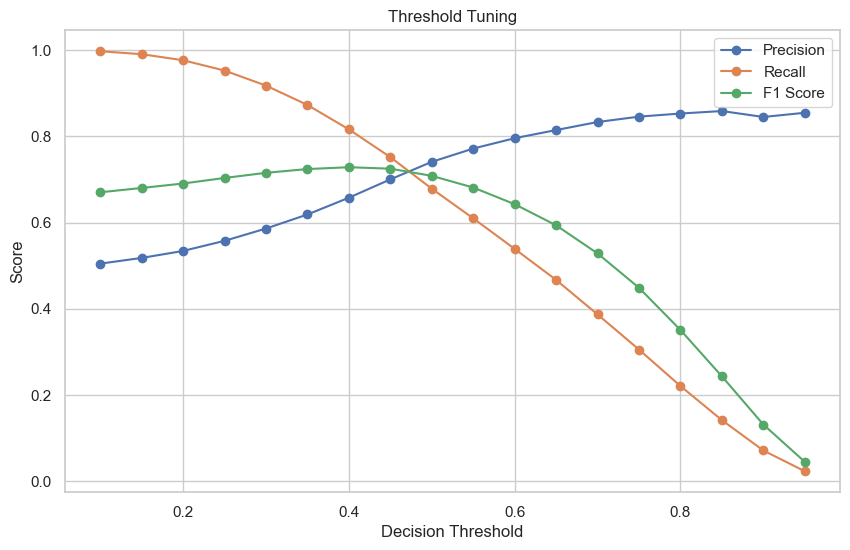

FINAL MODEL PERFORMANCE
Threshold : 0.4
Accuracy : 0.6971196237875967
Precision: 0.6575668597730339
Recall   : 0.8160330904077211
F1 Score : 0.7282794990112064


In [14]:
# =============================================================================
# PRECISION - RECALL vs THRESHOLD
# =============================================================================

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")

plt.ylabel("Score")

plt.title("Threshold Tuning")

plt.grid(True)

plt.legend()

plt.show()










# Select Best Threshold

# =============================================================================
# FINAL THRESHOLD
# =============================================================================

best_threshold = 0.40

final_prediction = (probabilities >= best_threshold).astype(int)

print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)

print("Threshold :", best_threshold)

print("Accuracy :", accuracy_score(y_test, final_prediction))
print("Precision:", precision_score(y_test, final_prediction))
print("Recall   :", recall_score(y_test, final_prediction))
print("F1 Score :", f1_score(y_test, final_prediction))

# ROC Curve

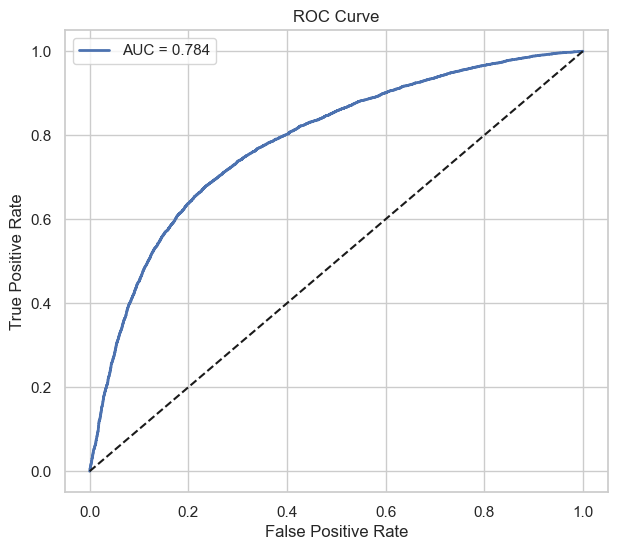

In [15]:
# =============================================================================
# ROC CURVE
# =============================================================================

from sklearn.metrics import roc_curve

# Probability from Best Model
y_prob = best_lr.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         linewidth=2,
         label=f"AUC = {roc_auc_score(y_test,y_prob):.3f}")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

# Resource Consumption Analysis

,Model,Training Time (s),Prediction Time (s),RAM Before (MB),RAM After (MB),Peak Memory (MB),Model Size (MB)
0,Logistic Regression,0.189128,0.000995,592.652344,594.835938,6.227758,0.000926
1,Random Forest,6.647125,0.286041,594.835938,592.667969,6.545451,16.144036
2,XGBoost,0.234893,0.010949,589.875000,592.027344,1.884499,0.264366


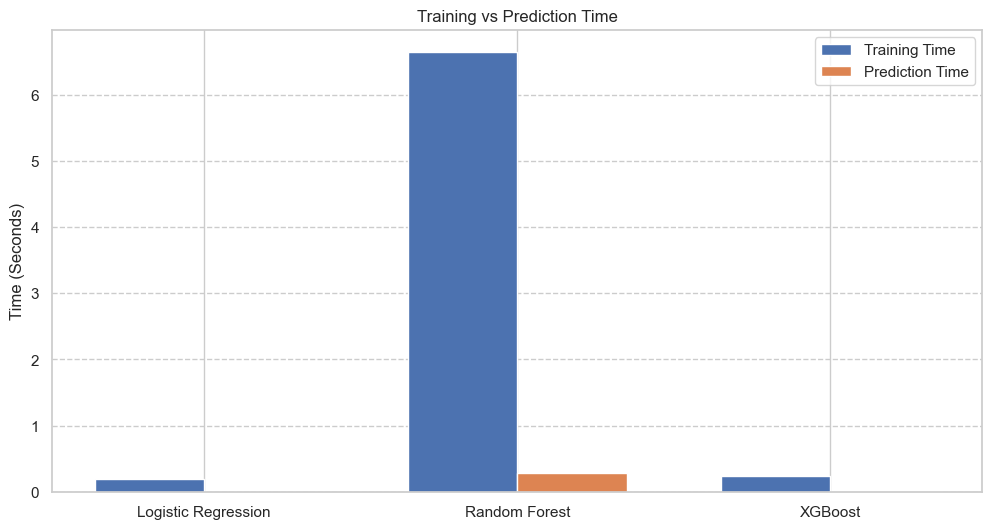

In [16]:
# =============================================================================
# RESOURCE CONSUMPTION ANALYSIS
# =============================================================================

import os
import time
import psutil
import tracemalloc

process = psutil.Process(os.getpid())

results = []

models = {
    "Logistic Regression": (best_lr, X_train_scaled, X_test_scaled),
    "Random Forest": (best_rf, X_train, X_test),
    "XGBoost": (best_xgb, X_train, X_test)
}

for name, (model, train_x, test_x) in models.items():

    tracemalloc.start()

    ram_before = process.memory_info().rss / (1024**2)

    start = time.time()
    model.fit(train_x, y_train)
    training_time = time.time() - start

    ram_after = process.memory_info().rss / (1024**2)

    current, peak = tracemalloc.get_traced_memory()

    tracemalloc.stop()

    start = time.time()
    model.predict(test_x)
    prediction_time = time.time() - start

    joblib.dump(model,"temp.pkl")

    model_size = os.path.getsize("temp.pkl")/(1024*1024)

    results.append([
        name,
        training_time,
        prediction_time,
        ram_before,
        ram_after,
        peak/(1024*1024),
        model_size
    ])

resource_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Training Time (s)",
        "Prediction Time (s)",
        "RAM Before (MB)",
        "RAM After (MB)",
        "Peak Memory (MB)",
        "Model Size (MB)"
    ]
)

display(resource_df)









plt.figure(figsize=(12,6))

x = np.arange(len(resource_df["Model"]))
w = 0.35

plt.bar(x-w/2, resource_df["Training Time (s)"], w, label="Training Time")
plt.bar(x+w/2, resource_df["Prediction Time (s)"], w, label="Prediction Time")

plt.xticks(x, resource_df["Model"])

plt.ylabel("Time (Seconds)")
plt.title("Training vs Prediction Time")

plt.legend()

plt.grid(axis="y", linestyle="--")

plt.show()

# Model Comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7220,0.7408,0.6785,0.7082,0.7836
1,Random Forest,0.7303,0.7550,0.6778,0.7143,0.7973
2,XGBoost,0.7302,0.7519,0.6830,0.7158,0.7986


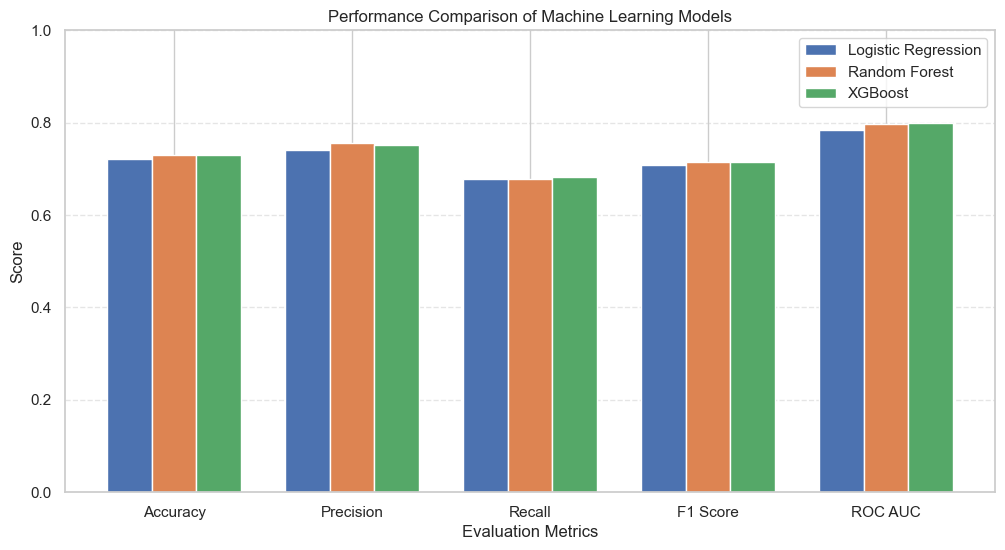

In [17]:
# =============================================================================
# MODEL PERFORMANCE COMPARISON
# =============================================================================

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, best_lr.predict(X_test_scaled)),
        accuracy_score(y_test, best_rf.predict(X_test)),
        accuracy_score(y_test, best_xgb.predict(X_test))
    ],

    "Precision": [
        precision_score(y_test, best_lr.predict(X_test_scaled)),
        precision_score(y_test, best_rf.predict(X_test)),
        precision_score(y_test, best_xgb.predict(X_test))
    ],

    "Recall": [
        recall_score(y_test, best_lr.predict(X_test_scaled)),
        recall_score(y_test, best_rf.predict(X_test)),
        recall_score(y_test, best_xgb.predict(X_test))
    ],

    "F1 Score": [
        f1_score(y_test, best_lr.predict(X_test_scaled)),
        f1_score(y_test, best_rf.predict(X_test)),
        f1_score(y_test, best_xgb.predict(X_test))
    ],

    "ROC AUC": [
        roc_auc_score(y_test, best_lr.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1])
    ]

})

comparison_df = comparison_df.round(4)

display(comparison_df)





# =============================================================================
# MODEL COMPARISON GRAPH
# =============================================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"]

plt.figure(figsize=(12,6))

bar_width = 0.25
x = np.arange(len(metrics))

plt.bar(
    x - bar_width,
    comparison_df.loc[0, metrics],
    width=bar_width,
    label="Logistic Regression"
)

plt.bar(
    x,
    comparison_df.loc[1, metrics],
    width=bar_width,
    label="Random Forest"
)

plt.bar(
    x + bar_width,
    comparison_df.loc[2, metrics],
    width=bar_width,
    label="XGBoost"
)

plt.xticks(x, metrics)
plt.ylim(0, 1)

plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")
plt.title("Performance Comparison of Machine Learning Models")

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


In [18]:
# =============================================================================
# BEST MODEL
# =============================================================================

best_model_name = comparison_df.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]["Model"]

print("="*70)
print("BEST MODEL")
print("="*70)

print(best_model_name)

BEST MODEL
XGBoost


#  Save Best Model

Best model saved successfully as 'best_model.pkl'


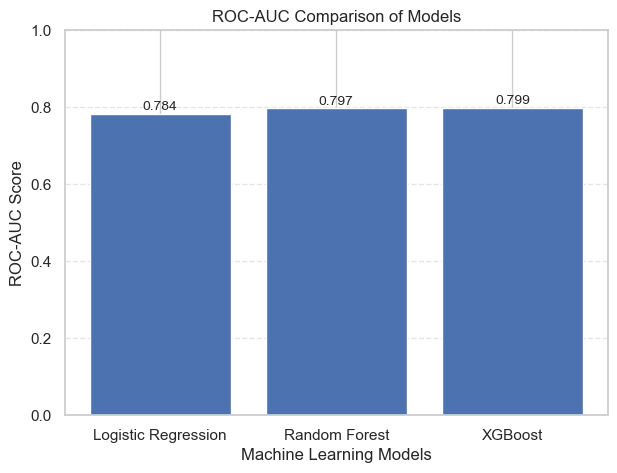

In [19]:
# =============================================================================
# SAVE BEST MODEL
# =============================================================================

import joblib

if best_model_name == "Logistic Regression":
    joblib.dump(best_lr, "best_model.pkl")

elif best_model_name == "Random Forest":
    joblib.dump(best_rf, "best_model.pkl")

else:
    joblib.dump(best_xgb, "best_model.pkl")

print("="*70)
print("Best model saved successfully as 'best_model.pkl'")
print("="*70)


# =============================================================================
# BEST MODEL BASED ON ROC-AUC
# =============================================================================

plt.figure(figsize=(7,5))

bars = plt.bar(
    comparison_df["Model"],
    comparison_df["ROC AUC"]
)

plt.ylabel("ROC-AUC Score")
plt.xlabel("Machine Learning Models")
plt.title("ROC-AUC Comparison of Models")

plt.ylim(0,1)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

# Sample Prediction

In [20]:
# =============================================================================
# SAMPLE PREDICTION
# =============================================================================

sample_patient = X.iloc[[0]]

if best_model_name == "Logistic Regression":

    probability = best_lr.predict_proba(
        scaler.transform(sample_patient)
    )[0][1]

else:

    if best_model_name == "Random Forest":
        probability = best_rf.predict_proba(sample_patient)[0][1]
    else:
        probability = best_xgb.predict_proba(sample_patient)[0][1]

prediction = "Disease" if probability >= 0.40 else "No Disease"

print("PATIENT PREDICTION")

print(f"Risk Score : {probability*100:.2f}%")
print(f"Prediction : {prediction}")

PATIENT PREDICTION
Risk Score : 16.22%
Prediction : No Disease


#  Project Conclusion

In [21]:
# =============================================================================
# PROJECT CONCLUSION
# =============================================================================


print("PROJECT COMPLETED SUCCESSFULLY")


print(f"Best Model : {best_model_name}")

print("\nModel is now ready for deployment using FastAPI.")
print("The saved model (best_model.pkl) can be integrated with a React frontend")
print("to provide real-time cardiovascular disease risk prediction.")

PROJECT COMPLETED SUCCESSFULLY
Best Model : XGBoost

Model is now ready for deployment using FastAPI.
The saved model (best_model.pkl) can be integrated with a React frontend
to provide real-time cardiovascular disease risk prediction.


**🎯 Student A Deliverables (Complete)**

**✅ Data Loading**

**✅ EDA**

**✅ Data Cleaning**

**✅ Feature Engineering (BMI)**

**✅ Train-Test Split**

**✅ Feature Scaling**

**✅ Logistic Regression**

**✅ Random Forest**

**✅ XGBoost**

**✅ GridSearchCV**

**✅ Threshold Tuning (High Recall)**

**✅ ROC Curve**

**✅ Resource Consumption Analysis

✅ Model Comparison (Table + Graph)

✅ Save Best Model (best_model.pkl)

✅ Save Scaler (scaler.pkl)

✅ Sample Prediction

✅ Project Conclusion**

**par mai kyun bananun kaya ye web app deploy ho jayega tab v mai yaise naye naye ceels babake code likhte trrhaunge nahi na toh av v baise hin karo**


**Healthcare Worker
        ↓
React Form

Age = 34
BP = 140
Cholesterol = 3
...
        ↓
Click "Predict"
        ↓
FastAPI receives JSON
        ↓
patient = pd.DataFrame([received_json])   ← Automatically
        ↓
Scaler.transform()
        ↓
model**




#  Paitient1  Testing

**Furthure  will be  yaken by  RestApi  , no need of  cells in  notebook**

In [22]:
# =============================================================================
# CUSTOM PATIENT PREDICTION
# =============================================================================

patient = pd.DataFrame({
    "age": [34],
    "gender": [1],
    "height": [170],
    "weight": [75],
    "ap_hi": [140],
    "ap_lo": [90],
    "cholesterol": [3],
    "gluc": [1],
    "smoke": [1],
    "alco": [0],
    "active": [1]
})

# Calculate BMI
patient["BMI"] = patient["weight"] / ((patient["height"]/100)**2)

# Keep same feature order as training data
patient = patient[X_train.columns]

display(patient)

# Prediction
prob = best_xgb.predict_proba(patient)[0][1]
pred = best_xgb.predict(patient)[0]

print("="*60)
print("PATIENT PREDICTION")
print("="*60)
print(f"Risk Score : {prob*100:.2f}%")
print("Prediction :", "Disease" if pred == 1 else "No Disease")

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,34,1,170,75,140,90,3,1,1,0,1,25.951557


PATIENT PREDICTION
Risk Score : 80.16%
Prediction : Disease


# Patient2 testing

In [23]:
# =============================================================================
# CUSTOM PATIENT PREDICTION
# =============================================================================

patient = pd.DataFrame({
    "age": [14],
    "gender": [2],
    "height": [10],
    "weight": [15],
    "ap_hi": [210],
    "ap_lo": [2120],
    "cholesterol": [3],
    "gluc": [1],
    "smoke": [1],
    "alco": [1],
    "active": [1]
})

# Calculate BMI
patient["BMI"] = patient["weight"] / ((patient["height"]/100)**2)

# Keep same feature order as training data
patient = patient[X_train.columns]

display(patient)

# Prediction
prob = best_xgb.predict_proba(patient)[0][1]
pred = best_xgb.predict(patient)[0]

print("="*60)
print("PATIENT PREDICTION")
print("="*60)
print(f"Risk Score : {prob*100:.2f}%")
print("Prediction :", "Disease" if pred == 1 else "No Disease")

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,14,2,10,15,210,2120,3,1,1,1,1,1500.0


PATIENT PREDICTION
Risk Score : 72.44%
Prediction : Disease


In [24]:
import os

print(os.getcwd())

c:\Users\GAURAV\Desktop\cardiovascular-risk-screening-system\notebooks
